In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict

c:\langraph_tutorial\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [3]:
class SubState(TypedDict):
    message: str
    hind_res : str

In [4]:
def trans_node(state: SubState) -> SubState:
    prompt = f'''
    convert this {state['message']} into hindi, keep it natural, dont add anything or make any assumption 
    '''
    response = llm.invoke(prompt)
    return {'hind_res': response}

In [5]:
subGraph = StateGraph(SubState)

subGraph.add_node('trans_node', trans_node)

subGraph.add_edge(START, 'trans_node')
subGraph.add_edge('trans_node', END)

SubGraph = subGraph.compile()

In [6]:
class ParState(TypedDict):
    topic: str
    eng_res: str
    hind_res: str

In [7]:
def par_node(state: ParState) -> ParState:
    prompt = f'''
    generate a short summary on the topic {state['topic']} in 2 lines.
    '''
    response = llm.invoke(prompt)
    return {'eng_res': response}

In [8]:
def trans_node(state: ParState) -> ParState:
    response = SubGraph.invoke({'message': state['eng_res']})
    
    return {'hind_res': response['hind_res']}

In [10]:
parent = StateGraph(ParState)

parent.add_node('summarise', par_node)
parent.add_node('translate', trans_node)

parent.add_edge(START, 'summarise')
parent.add_edge('summarise', 'translate')
parent.add_edge('translate', END)

chatbot = parent.compile()

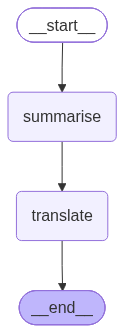

In [11]:
chatbot

In [12]:
initial_state = {'topic': 'corona'}

In [13]:
final_output = chatbot.invoke(initial_state)

In [14]:
final_output

{'topic': 'corona',
 'eng_res': AIMessage(content='The coronavirus (SARS-CoV-2) sparked the global COVID-19 pandemic, a respiratory illness. It profoundly impacted health, economies, and societies worldwide.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fe2ea-04f9-7653-84a1-28139c380dbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 821, 'total_tokens': 839, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 788}}),
 'hind_res': AIMessage(content='कोरोनावायरस (SARS-CoV-2) ने वैश्विक COVID-19 महामारी को जन्म दिया, जो एक श्वसन संबंधी बीमारी है। इसने दुनिया भर में स्वास्थ्य, अर्थव्यवस्थाओं और समाजों को गहराई से प्रभावित किया।', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='l